# RoBERTa Sentiment Analysis — All 5k YouTube Comments
Full pipeline: fetch all rows from Supabase → clean/filter → RoBERTa inference → CSV export → visualizations.

In [1]:
# ── 1. Install dependencies ──────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "supabase", "transformers", "torch", "pandas",
                "matplotlib", "seaborn", "tqdm", "wordcloud"], check=True)
print("All packages ready.")

All packages ready.


In [2]:
# ── 2. Imports ────────────────────────────────────────────────────────────────
import re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from supabase import create_client, Client
from transformers import pipeline

sns.set_theme(style="whitegrid", palette="muted")
print("Imports OK.")

/Users/deepikadasari/Documents/Abhi/SCU/ClubsProjectsResearch/Research/ProfGhoshResearch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK.


In [ ]:
# ── 3. Fetch ALL rows from Supabase (paginated) ───────────────────────────────

supabase: Client = create_client(SUPABASE_URL, SUPABASE_KEY)

PAGE_SIZE = 1000   # Supabase hard cap per request
all_rows  = []
page      = 0

print("Fetching all rows from Supabase ...")
while True:
    start = page * PAGE_SIZE
    end   = start + PAGE_SIZE - 1
    resp  = (
        supabase.table("YoutubeComments")
        .select("id, Video_Id, Video_title, Comment_Text")
        .range(start, end)
        .execute()
    )
    batch = resp.data
    if not batch:
        break
    all_rows.extend(batch)
    print(f"  page {page+1}: fetched {len(batch)} rows  (total so far: {len(all_rows)})")
    if len(batch) < PAGE_SIZE:
        break
    page += 1

raw_df = pd.DataFrame(all_rows)
print(f"\nTotal rows fetched: {len(raw_df)}")
print(raw_df.dtypes)
raw_df.head()

Fetching all rows from Supabase ...
  page 1: fetched 1000 rows  (total so far: 1000)
  page 2: fetched 1000 rows  (total so far: 2000)
  page 3: fetched 1000 rows  (total so far: 3000)
  page 4: fetched 1000 rows  (total so far: 4000)
  page 5: fetched 434 rows  (total so far: 4434)

Total rows fetched: 4434
id              int64
Video_Id          str
Video_title       str
Comment_Text      str
dtype: object


,id,Video_Id,Video_title,Comment_Text
0,1300,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,"Please, don't trust AI with your private infor..."
1,1301,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,People need to do better and stop treating eac...
2,8,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,"Yes 100%. It makes therapists 100% obsolete, n..."
3,12,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,I wouldn't mind talking to an AI therapist in ...
4,610,1s86iGccirA,Use Chat-GPT as a THERAPIST,Nooooo. Can’t believe he’s thinks this is a go...


In [ ]:
# ── 4. Clean & filter ─────────────────────────────────────────────────────────

#Something copilot added to filter out emojis and useless comments
EMOJI_RE    = re.compile(
    "["
    "\U0001F600-\U0001FFFF"   # emoticons
    "\U00002700-\U000027BF"   # dingbats
    "\U0001F300-\U0001F5FF"   # symbols & pictographs
    "\U0001F900-\U0001F9FF"   # supplemental symbols
    "\U0001FA00-\U0001FA6F"   # chess, etc.
    "\U00002600-\U000026FF"   # misc symbols
    "]+", flags=re.UNICODE
)
URL_RE      = re.compile(r'https?://\S+|www\.\S+', re.IGNORECASE)
HANDLE_RE   = re.compile(r'@\w+')

def is_useless(text: str) -> bool:
    """Return True if the comment should be discarded."""
    if not isinstance(text, str):
        return True
    stripped = text.strip()
    # Too short
    if len(stripped) < 10:
        return True
    # After stripping emojis, URLs, handles and punctuation — nothing left?
    cleaned = EMOJI_RE.sub('', stripped)
    cleaned = URL_RE.sub('', cleaned)
    cleaned = HANDLE_RE.sub('', cleaned)
    cleaned = re.sub(r'[^\w\s]', '', cleaned).strip()
    if len(cleaned) < 5:
        return True
    # All digits / numbers only
    if re.fullmatch(r'[\d\s]+', cleaned):
        return True
    return False

df = raw_df.copy()
df['Comment_Text'] = df['Comment_Text'].astype(str).str.strip()

before = len(df)
df = df[~df['Comment_Text'].apply(is_useless)]
df = df.drop_duplicates(subset=['Comment_Text'])
df = df.reset_index(drop=True)
after = len(df)

print(f"Rows before filtering : {before}")
print(f"Rows after  filtering : {after}  ({before - after} removed)")
df.head()

Rows before filtering : 4434
Rows after  filtering : 2647  (1787 removed)


,id,Video_Id,Video_title,Comment_Text
0,1300,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,"Please, don't trust AI with your private infor..."
1,1301,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,People need to do better and stop treating eac...
2,8,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,"Yes 100%. It makes therapists 100% obsolete, n..."
3,12,3BgdhHXJ-CU,Can AI Replace Therapists? | Psychiatrist Expl...,I wouldn't mind talking to an AI therapist in ...
4,610,1s86iGccirA,Use Chat-GPT as a THERAPIST,Nooooo. Can’t believe he’s thinks this is a go...


In [ ]:
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
print(f"Loading model: {MODEL_NAME}  (download only needed once) ...")
sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=MODEL_NAME,
    truncation=True,
    max_length=512,
    device=-1,          
)
print("Model ready.")

Loading model: cardiffnlp/twitter-roberta-base-sentiment-latest  (download only needed once) ...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2246.72it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready.


In [6]:
# ── 6. Run inference in batches ───────────────────────────────────────────────
# Colab T4 GPU tip: set device=0 above and BATCH_SIZE=64 for ~10× speed.

#Utilizing The Google t$ GPU
BATCH_SIZE = 32

texts  = df['Comment_Text'].tolist()
labels = []
scores = []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="RoBERTa inference"):
    batch   = texts[i : i + BATCH_SIZE]
    results = sentiment_pipe(batch)
    for r in results:
        labels.append(r['label'])
        scores.append(round(r['score'], 6))

df['Sentiment_Label'] = labels
df['Sentiment_Score'] = scores

print(f"\nInference done on {len(df)} comments.")
df[['Comment_Text','Sentiment_Label','Sentiment_Score']].head(10)

RoBERTa inference: 100%|██████████| 83/83 [02:42<00:00,  1.96s/it]


Inference done on 2647 comments.


,Comment_Text,Sentiment_Label,Sentiment_Score
0,"Please, don't trust AI with your private infor...",negative,0.742094
1,People need to do better and stop treating eac...,negative,0.730849
2,"Yes 100%. It makes therapists 100% obsolete, n...",negative,0.771455
3,I wouldn't mind talking to an AI therapist in ...,positive,0.768634
4,Nooooo. Can’t believe he’s thinks this is a go...,negative,0.897345
5,I don't think AI could replace therapist. I al...,negative,0.842826
6,"No doubt, human interaction will never be repl...",positive,0.562589
7,Nothing like the real thing,negative,0.516095
8,"That’s a big conceptual jump, from computerize...",neutral,0.589411
9,I hve been using AI therapy as a tool for a ye...,positive,0.507660


In [7]:
# ── 7. Save to CSV ────────────────────────────────────────────────────────────
import os

# Resolve output dir: works on Colab, local Jupyter from project root, or notebook dir.
IS_COLAB = os.path.exists('/content')
if IS_COLAB:
    OUT_DIR = '/content'
elif os.path.basename(os.getcwd()) == 'robertaSentimentAnalysis':
    OUT_DIR = os.getcwd()
elif os.path.isdir(os.path.join(os.getcwd(), 'robertaSentimentAnalysis')):
    OUT_DIR = os.path.join(os.getcwd(), 'robertaSentimentAnalysis')
else:
    OUT_DIR = os.getcwd()

CSV_PATH = os.path.join(OUT_DIR, 'sentiment_results_5k.csv')

df.to_csv(CSV_PATH, index=False)
print(f"CSV saved → {CSV_PATH}")
print(f"Shape: {df.shape}")

# If on Colab, offer a download
if IS_COLAB:
    try:
        from google.colab import files
        files.download(CSV_PATH)
        print("Download triggered in Colab.")
    except Exception:
        pass

CSV saved → /Users/deepikadasari/Documents/Abhi/SCU/ClubsProjectsResearch/Research/ProfGhoshResearch/robertaSentimentAnalysis/sentiment_results_5k.csv
Shape: (2647, 6)


In [8]:
# ── 8. Summary statistics ─────────────────────────────────────────────────────
print("=" * 60)
print("SENTIMENT DISTRIBUTION (all filtered comments)")
print("=" * 60)
counts = df['Sentiment_Label'].value_counts()
pcts   = df['Sentiment_Label'].value_counts(normalize=True).mul(100).round(2)
summary = pd.DataFrame({'Count': counts, 'Percent(%)': pcts})
print(summary.to_string())

print("\n" + "=" * 60)
print("MEAN CONFIDENCE SCORE BY LABEL")
print("=" * 60)
score_summary = (
    df.groupby('Sentiment_Label')['Sentiment_Score']
    .agg(['mean','median','std','min','max'])
    .round(4)
)
print(score_summary.to_string())

print("\n" + "=" * 60)
print("TOP-10 MOST COMMON EXACT COMMENT TEXTS")
print("=" * 60)
print(df['Comment_Text'].value_counts().head(10).to_string())

SENTIMENT DISTRIBUTION (all filtered comments)
                 Count  Percent(%)
Sentiment_Label                   
negative          1133       42.80
neutral            823       31.09
positive           691       26.11

MEAN CONFIDENCE SCORE BY LABEL
                   mean  median     std     min     max
Sentiment_Label                                        
negative         0.7497  0.7738  0.1403  0.3530  0.9577
neutral          0.6452  0.6254  0.1364  0.3439  0.9509
positive         0.7932  0.8408  0.1720  0.3372  0.9901

TOP-10 MOST COMMON EXACT COMMENT TEXTS
Comment_Text
Please, don't trust AI with your private information, those companies are working to make super intelligence, that is the next step in the race, which will be dangerous. Listen to the cy ersecurity experts that are warning us about it.                                                                                                         1
People need to do better and stop treating each other as commodities to

In [ ]:
#Emotion detection using RoBERTa 



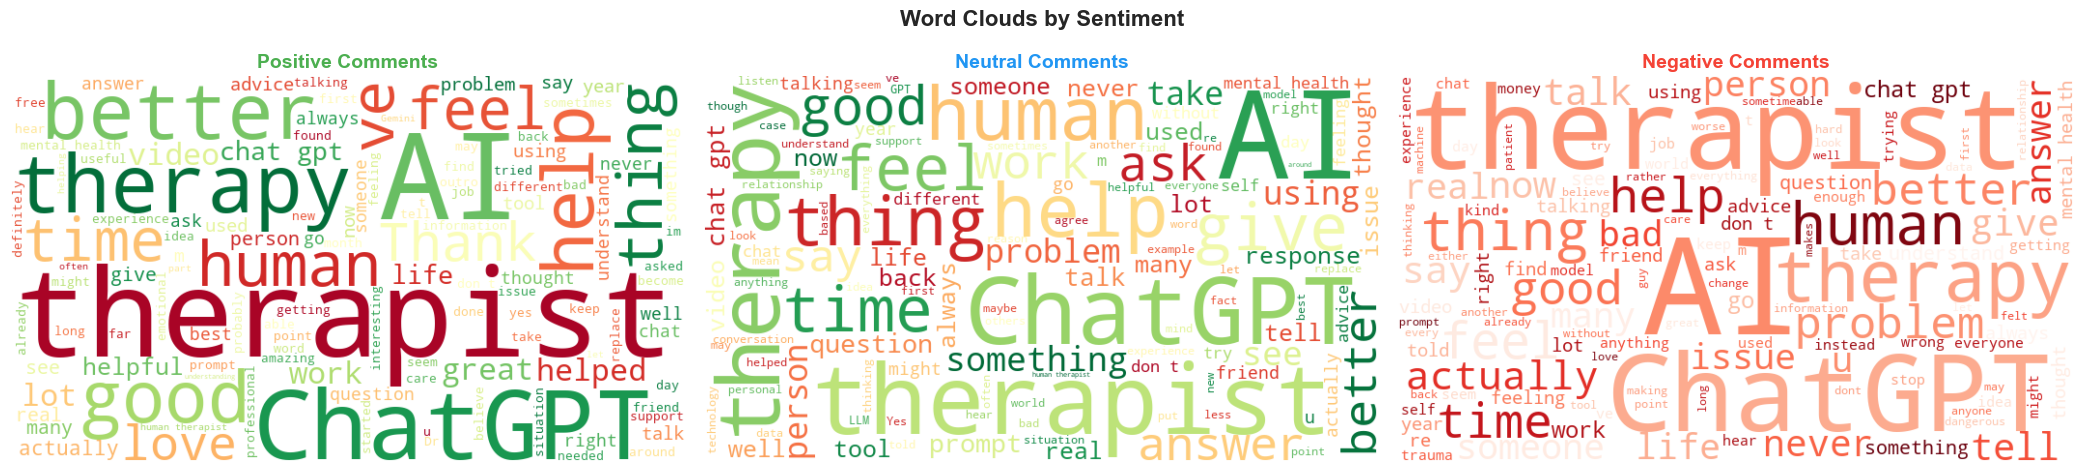

Word clouds saved → /Users/deepikadasari/Documents/Abhi/SCU/ClubsProjectsResearch/Research/ProfGhoshResearch/robertaSentimentAnalysis/wordclouds_5k.png


In [ ]:
# ── 10. Word clouds per sentiment (bonus from GPT) ─────────────────────────────────────
try:
    from wordcloud import WordCloud, STOPWORDS

    STOP = set(STOPWORDS) | {'s', 'will', 'one', 'know', 'also', 'even',
                               'really', 'just', 'like', 'people', 'think',
                               'get', 'got', 'make', 'made', 'much', 'way',
                               'can', 'still', 'want', 'would', 'could',
                               'need', 'going', 'come', 'said', 'use'}

    fig2, wc_axes = plt.subplots(1, len(ordered_labels), figsize=(7*len(ordered_labels), 5))
    if len(ordered_labels) == 1:
        wc_axes = [wc_axes]

    for ax, label, color in zip(wc_axes, ordered_labels, pal):
        text_blob = ' '.join(df.loc[df['Sentiment_Label']==label, 'Comment_Text'].tolist())
        wc = WordCloud(
            width=700, height=400, background_color='white',
            stopwords=STOP, max_words=120,
            colormap='RdYlGn' if label!='negative' else 'Reds'
        ).generate(text_blob)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{label.capitalize()} Comments', fontsize=14, fontweight='bold', color=color)

    plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
    plt.tight_layout()
    WC_PATH = os.path.join(OUT_DIR, 'wordclouds_5k.png')
    plt.savefig(WC_PATH, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Word clouds saved → {WC_PATH}")
except ImportError:
    print("wordcloud not installed — skipping word-cloud cell.")